In [ ]:
#U = 2.0
#g = 0.8
#Nk = 256
#mu =  -0.6741610738255033 dopping_x = 0.1535385142149972 Tc = 0.001713534134609854
#mu = -1.132214765100671 dopping_x = 0.3218996681540329 Tc = 0.06687342050007622
#mu =  -1.241275167785235 dopping_x = 0.38645948958637044 Tc = 0.07605844333106182
#mu =  -1.2630872483221476 dopping_x = 0.39939180815416475 Tc = 0.07607920809117699

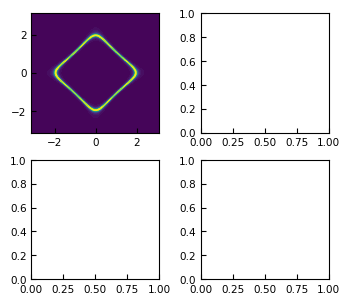

<Figure size 800x800 with 0 Axes>

In [3]:
#Fermi arc model density polt
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import matplotlib.cm as cm
import time

plt.style.use("publication.mplstyle")
fig, axs = plt.subplots(2, 2, figsize=(3.386, 2.093*1.4))

kB = 1.0
t = 1.0

t1 = -0.2
t2 = 0.1

Q = [np.pi, np.pi]

def band(kx, ky):
    return -2.0*t*(np.cos(kx) + np.cos(ky)) - 4.0*t1*np.cos(kx)*np.cos(ky) - 2*t2*(np.cos(2*kx) + np.cos(2*ky))

def band_Q(kx, ky):
    return -2.0*t*(np.cos(kx+Q[0]) + np.cos(ky+Q[1])) - 4.0*t1*np.cos(kx+Q[0])*np.cos(ky+Q[1]) - 2*t2*(np.cos(2*(kx+Q[0])) + np.cos(2*(ky+Q[1])))

def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_Q_minus_mu
    E_2 = -beta*(epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta*epsilon_minus_mu
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + np.exp(E_3 - E_max) + np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    return 2.0*np.sum(n_k) / N

def lorentzian(x, delta=0.04):
    return delta / (np.pi * (x * x + delta * delta))

def spectrum(kx, ky, omega, epsilon, epsilon_Q, mu, U, T):
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    spectrum = (1 - n_k)*lorentzian(omega - (band(kx, ky) - mu)) + n_k*lorentzian(omega - (band(kx, ky) - mu) - U)
    return spectrum

U = 2.0
#T = 0.001713534134609854
# T = 0
# mu = -0.674

# T = 0.07605844333106182
# mu = -1.24

T = 0
mu = -1.6

##T = 0.06687342050007622
#mu = -1.13

# T = 0
# mu = -1.6


Nk = 256
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

spectrum_2d = np.full_like(KX, 0)
epsilon = band(KX, KY)
epsilon_Q = band_Q(KX, KY)
spectrum_2d = spectrum(KX, KY, 0, epsilon, epsilon_Q, mu, U, T)

fig = plt.figure(figsize=(8, 8))
N_levels = 40
#np.save(f'spectrum_K{Nk}_U={U}_mu={mu}', spectrum_2d)
axs[0, 0].contourf(KX, KY, spectrum_2d, cmap="viridis", levels=N_levels)

In [9]:
1-average_occupation(mu, T, U, KX, KY, N)

0.3532206217446411

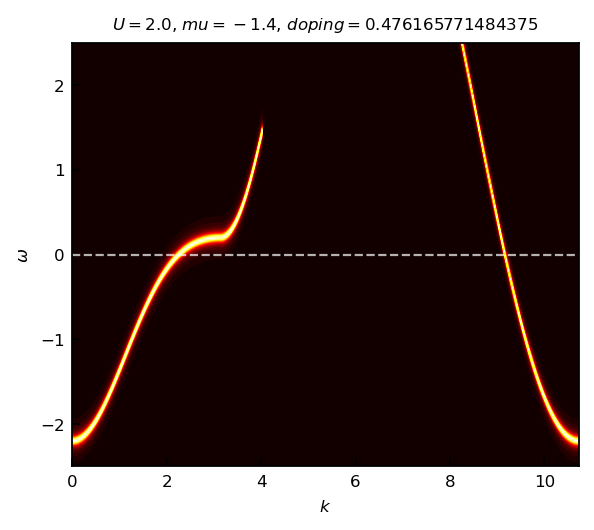

In [9]:
#single-pariticle spectrum along the path G-X-M-G
numk = 200
Gpt = np.array([0.0, 0.0])
Xpt = np.array([np.pi, 0.0])
Mpt = np.array([np.pi, np.pi])
GX = np.linalg.norm(Xpt - Gpt)
XM = np.linalg.norm(Mpt - Xpt)
MG = np.linalg.norm(Gpt - Mpt)
kxGX = np.linspace(Gpt[0], Xpt[0], numk, endpoint=False)
kyGX = np.linspace(Gpt[1], Xpt[1], numk, endpoint=False)
kxXM = np.linspace(Xpt[0], Mpt[0], numk, endpoint=False)
kyXM = np.linspace(Xpt[1], Mpt[1], numk, endpoint=False)
kxMG = np.linspace(Mpt[0], Gpt[0], numk + 1)
kyMG = np.linspace(Mpt[1], Gpt[1], numk + 1)
kpathx = np.concatenate((kxGX, kxXM, kxMG))
kpathy = np.concatenate((kyGX, kyXM, kyMG))
klen = np.zeros(kpathx.size)
for i in range(1, klen.size):
    klen[i] = klen[i - 1] + np.sqrt(np.square(kpathx[i] - kpathx[i - 1]) + np.square(kpathy[i] - kpathy[i - 1]))

numomega = numk
omega_min = -2.5
omega_max = 2.5
omega_list = np.linspace(omega_min, omega_max, numomega) 
spectrum_2d = np.zeros((len(omega_list), len(kpathx)))

U = 2.0
#T = 0.001713534134609854
#T = 0.05
T = 0
# mu = -0.674

#T = 0.07605844333106182
#T = 0.05
# mu = -1.24
# mu = -1.2
mu = -1.4


for i in range(numomega):
    for j in range(len(kpathx)):
        kx = kpathx[j]
        ky = kpathy[j]
        epsilon = band(kx, ky)
        epsilon_Q = band_Q(kx, ky)
        spectrum_2d[i, j] = spectrum(kx, ky, omega_list[i], epsilon, epsilon_Q, mu, U, T)

Klen, Omega_list = np.meshgrid(klen, omega_list)

plt.figure(figsize=(3.6, 3.2), dpi=160)
N_levels = 40
# np.save(f'band_K{Nk}_U={U}_mu={mu}', spectrum_2d)
# np.save(f'Kpath_NK{numk}', Klen)
C = plt.contourf(Klen, Omega_list, spectrum_2d, cmap="hot", levels=N_levels)
plt.title(rf"$U={U}$, $mu={mu}$, $doping={1-average_occupation(mu, T, U, KX, KY, N)}$")
line_x = [0, 10.72606825]
line_y = [0, 0]
plt.xlabel(r"$k$")
plt.ylabel(r"$\omega$")
plt.plot(line_x, line_y, color='white', linestyle='--', linewidth=1, alpha=0.7)
plt.savefig("spectrum.png", bbox_inches="tight")

0
0
0


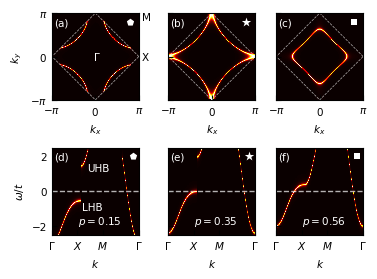

In [ ]:
#plot mu = -0.678, mu = -1.2, mu = -1.6
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

#plt.figure(figsize=(8, 8))
import matplotlib.pyplot as plt
plt.style.use("publication.mplstyle")
#plt.rcParams['mathtext.fontset'] = 'stix'
#fig, axs = plt.subplots(2, 3, figsize=(3.386*1.37, 2.093*1.57), sharey='row')
fig, axs = plt.subplots(2, 3, figsize=(8.6/2.54*1.08, 6.3/2.54*1.08), sharey='row')

Nk = 256
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

numk = 200
Gpt = np.array([0.0, 0.0])
Xpt = np.array([np.pi, 0.0])
Mpt = np.array([np.pi, np.pi])
GX = np.linalg.norm(Xpt - Gpt)
XM = np.linalg.norm(Mpt - Xpt)
MG = np.linalg.norm(Gpt - Mpt)
kxGX = np.linspace(Gpt[0], Xpt[0], numk, endpoint=False)
kyGX = np.linspace(Gpt[1], Xpt[1], numk, endpoint=False)
kxXM = np.linspace(Xpt[0], Mpt[0], numk, endpoint=False)
kyXM = np.linspace(Xpt[1], Mpt[1], numk, endpoint=False)
kxMG = np.linspace(Mpt[0], Gpt[0], numk + 1)
kyMG = np.linspace(Mpt[1], Gpt[1], numk + 1)
kpathx = np.concatenate((kxGX, kxXM, kxMG))
kpathy = np.concatenate((kyGX, kyXM, kyMG))
klen = np.zeros(kpathx.size)
for i in range(1, klen.size):
    klen[i] = klen[i - 1] + np.sqrt(np.square(kpathx[i] - kpathx[i - 1]) + np.square(kpathy[i] - kpathy[i - 1]))

numomega = numk
omega_min = -2.5
omega_max = 2.5
omega_list = np.linspace(omega_min, omega_max, numomega) 
spectrum_2d = np.zeros((len(omega_list), len(kpathx)))
Klen, Omega_list = np.meshgrid(klen, omega_list)

U = 2.0
mu = -0.674
spectrum_0 = np.load(f'spectrum_K{Nk}_U={U}_mu={mu}.npy')
N_levels = 40
extent = [KX.min(), KX.max(), KY.min(), KY.max()]
axs[0, 0].imshow(spectrum_0, extent=extent, origin='lower', aspect='auto', interpolation='none', cmap="hot")
axs[0, 0].set_xlabel(r'$k_x$')
#axs[0, 0].set_ylabel(r'$k_y$', rotation='horizontal')
axs[0, 0].set_ylabel(r'$k_y$')
axs[0, 0].set_xticks([-np.pi, 0, np.pi])
axs[0, 0].set_yticks([-np.pi, 0, np.pi])
axs[0, 0].set_yticklabels([r'$-\pi$', r'$0$', r'$\pi$'])
axs[0, 0].set_xticklabels([r'$-\pi$', r'$0$', r'$\pi$'])

U = 2.0
mu = -1.2
spectrum_0 = np.load(f'spectrum_K{Nk}_U={U}_mu={mu}.npy')
extent = [KX.min(), KX.max(), KY.min(), KY.max()]
axs[0, 1].imshow(spectrum_0, extent=extent, origin='lower', aspect='auto', interpolation='none', cmap="hot")
axs[0, 1].set_xlabel(r'$k_x$')
#axs[1, 0].set_ylabel(r'$k_y$', rotation='horizontal')
#axs[0, 1].set_ylabel(r'$k_y$')
axs[0, 1].set_xticks([-np.pi, 0, np.pi])
axs[0, 1].set_yticks([-np.pi, 0, np.pi])
axs[0, 1].set_yticklabels([r'$-\pi$', r'$0$', r'$\pi$'])
axs[0, 1].set_xticklabels([r'$-\pi$', r'$0$', r'$\pi$'])

U = 2.0
mu = -1.6
spectrum_0 = np.load(f'spectrum_K{Nk}_U={U}_mu={mu}.npy')
N_levels = 40
extent = [KX.min(), KX.max(), KY.min(), KY.max()]
axs[0, 2].imshow(spectrum_0, extent=extent, origin='lower', aspect='auto', interpolation='none', cmap="hot")
axs[0, 2].set_xlabel(r'$k_x$')
#axs[0, 0].set_ylabel(r'$k_y$', rotation='horizontal')
#axs[0, 2].set_ylabel(r'$k_y$')
axs[0, 2].set_xticks([-np.pi, 0, np.pi])
axs[0, 2].set_yticks([-np.pi, 0, np.pi])
axs[0, 2].set_yticklabels([r'$-\pi$', r'$0$', r'$\pi$'])
axs[0, 2].set_xticklabels([r'$-\pi$', r'$0$', r'$\pi$'])

Klen = np.load(f'Kpath_NK{numk}.npy')
spectrum_2d = np.zeros((len(omega_list), len(kpathx)))

U = 2.0
mu = -0.674
spectrum_2d_0 = np.load(f'band_K{Nk}_U={U}_mu={mu}.npy')
extent = [Klen.min(), Klen.max(), Omega_list.min(), Omega_list.max()]
axs[1, 0].imshow(spectrum_2d_0, extent=extent, origin='lower', aspect='auto', interpolation='none', cmap="hot")
line_x = [0, 10.72606825]
line_y = [0, 0]
axs[1, 0].plot(line_x, line_y, color='white', linestyle='--', linewidth=1, alpha=0.7)
axs[1, 0].set_ylabel(r'$\omega/t$')
axs[1, 0].set_xticks([0, Klen[0, numk], Klen[0, 2*numk], Klen[0, 3*numk]])
axs[1, 0].set_xticklabels([r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$'])
axs[1, 0].set_xlabel(r'$k$')
x_0 = round(1 - average_occupation(mu, T, U, KX, KY, N), 2)
print(T)
#axs[0, 1].annotate(
#    rf'$x = 1-\langle n\rangle$ = {x}',
#    xy=(1.02, 0.5),
#    xycoords='axes fraction', 
#    rotation=-90,
#    verticalalignment='center'
#)

U = 2.0
mu = -1.2
spectrum_2d_0 = np.load(f'band_K{Nk}_U={U}_mu={mu}.npy')
extent = [Klen.min(), Klen.max(), Omega_list.min(), Omega_list.max()]
axs[1, 1].imshow(spectrum_2d_0, extent=extent, origin='lower', aspect='auto', interpolation='none', cmap="hot")
axs[1, 1].plot(line_x, line_y, color='white', linestyle='--', linewidth=1, alpha=0.7)
#axs[1, 1].set_ylabel(r'$\omega/t$')
axs[1, 1].set_xticks([0, Klen[0, numk], Klen[0, 2*numk], Klen[0, 3*numk]])
axs[1, 1].set_xticklabels([r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$'])
axs[1, 1].set_xlabel(r'$k$')
x_1 = round(1 - average_occupation(mu, T, U, KX, KY, N), 2)
print(T)

U = 2.0
mu = -1.6
spectrum_2d_0 = np.load(f'band_K{Nk}_U={U}_mu={mu}.npy')
extent = [Klen.min(), Klen.max(), Omega_list.min(), Omega_list.max()]
axs[1, 2].imshow(spectrum_2d_0, extent=extent, origin='lower', aspect='auto', interpolation='none', cmap="hot")
line_x = [0, 10.72606825]
line_y = [0, 0]
axs[1, 2].plot(line_x, line_y, color='white', linestyle='--', linewidth=1, alpha=0.7)
#axs[1, 2].set_ylabel(r'$\omega/t$')
axs[1, 2].set_xticks([0, Klen[0, numk], Klen[0, 2*numk], Klen[0, 3*numk]])
axs[1, 2].set_xticklabels([r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$'])
axs[1, 2].set_xlabel(r'$k$')
x_2 = round(1 - average_occupation(mu, T, U, KX, KY, N), 2)
print(T)

#axs[1, 1].annotate(
#    rf'$x = 1-\langle n\rangle$ = {x}',
#    xy=(1.02, 0.5),
#    xycoords='axes fraction', 
#    rotation=-90,
#    verticalalignment='center'
#)
axs[0, 0].set_aspect('equal')
axs[1, 0].set_aspect((Klen.min()-Klen.max())/(Omega_list.min()-Omega_list.max()))
axs[0, 1].set_aspect('equal')
axs[1, 1].set_aspect((Klen.min()-Klen.max())/(Omega_list.min()-Omega_list.max()))
axs[0, 2].set_aspect('equal')
axs[1, 2].set_aspect((Klen.min()-Klen.max())/(Omega_list.min()-Omega_list.max()))

axs[0, 0].annotate(rf'(a)', xy=(0.02, 0.86), xycoords='axes fraction', color='white')
axs[1, 0].annotate(rf'(d)', xy=(0.02, 0.86), xycoords='axes fraction', color='white')
axs[1, 0].annotate(rf'$p = {x_0}$', xy=(0.3, 0.12), xycoords='axes fraction', color='white')
axs[0, 1].annotate(rf'(b)', xy=(0.02, 0.86), xycoords='axes fraction', color='white')
axs[1, 1].annotate(rf'(e)', xy=(0.02, 0.86), xycoords='axes fraction', color='white')
axs[1, 1].annotate(rf'$p = {x_1}$', xy=(0.3, 0.12), xycoords='axes fraction', color='white')
axs[0, 2].annotate(rf'(c)', xy=(0.02, 0.86), xycoords='axes fraction', color='white')
axs[1, 2].annotate(rf'(f)', xy=(0.02, 0.86), xycoords='axes fraction', color='white')
axs[1, 2].annotate(rf'$p = {x_2}$', xy=(0.3, 0.12), xycoords='axes fraction', color='white')

afbz_kx = [np.pi, 0, -np.pi, 0, np.pi]
afbz_ky = [0, np.pi, 0, -np.pi, 0]

axs[0, 0].plot(afbz_kx, afbz_ky, color='white', linestyle='--', linewidth=0.5, alpha=0.7)
axs[0, 1].plot(afbz_kx, afbz_ky, color='white', linestyle='--', linewidth=0.5, alpha=0.7)
axs[0, 2].plot(afbz_kx, afbz_ky, color='white', linestyle='--', linewidth=0.5, alpha=0.7)
axs[0, 0].set_xlim(-np.pi, np.pi)
axs[0, 0].set_ylim(-np.pi, np.pi)
axs[0, 1].set_xlim(-np.pi, np.pi)
axs[0, 1].set_ylim(-np.pi, np.pi)
axs[0, 2].set_xlim(-np.pi, np.pi)
axs[0, 2].set_ylim(-np.pi, np.pi)

axs[1, 0].annotate(rf'UHB', xy=(0.40, 0.73), xycoords='axes fraction', color='white')
axs[1, 0].annotate(rf'LHB', xy=(0.35, 0.28), xycoords='axes fraction', color='white')

#axs[0, 0].scatter(2.5, 2.5, s=30, marker='p', color='white', linewidths=10, zorder=4)
axs[0, 0].scatter(2.5, 2.5, 
                  s=30,            # 增大点的大小，方便观察效果
                  marker='p',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.0,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=4)
axs[1, 0].scatter(10, 2.0, 
                  s=30,            # 增大点的大小，方便观察效果
                  marker='p',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.0,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=4)

axs[0, 2].scatter(2.5, 2.5, 
                  s=15,            # 增大点的大小，方便观察效果
                  marker='s',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.0,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=4)
axs[1, 2].scatter(10, 2.0, 
                  s=15,            # 增大点的大小，方便观察效果
                  marker='s',       # 五边形
                  facecolors='white',# 填充颜色
                  edgecolors='black',# 边框颜色
                  linewidths=0.0,     # 边框粗细，建议不要太大，否则会遮挡形状
                  zorder=4)

axs[0, 1].scatter(2.5, 2.5, s=50, marker='*', color='white', linewidths=0, zorder=4, alpha = 1)
#axs[2, 0].scatter(10, 2.0, s=30, marker='p', color='tab:cyan', linewidths=0, zorder=4)
axs[1, 1].scatter(10, 2.0, s=50, marker='*', color='white', linewidths=0, zorder=4, alpha = 1)

axs[0, 0].annotate(rf'$\mathrm{{\Gamma}}$', xy=(0.47, 0.46), xycoords='axes fraction', color='white')
axs[0, 0].annotate(rf'$\mathrm{{X}}$', xy=(1.03, 0.46), xycoords='axes fraction', color='black')
axs[0, 0].annotate(rf'$\mathrm{{M}}$', xy=(1.03, 0.92), xycoords='axes fraction', color='black')

#axs[0, 1].annotate(rf'$\mathrm{{\Gamma}}$', xy=(0.47, 0.46), xycoords='axes fraction', color='white')
#axs[0, 1].annotate(rf'$\mathrm{{X}}$', xy=(1.03, 0.46), xycoords='axes fraction', color='black')
#axs[0, 1].annotate(rf'$\mathrm{{M}}$', xy=(1.03, 0.96), xycoords='axes fraction', color='black')


plt.savefig(f'spectrum')


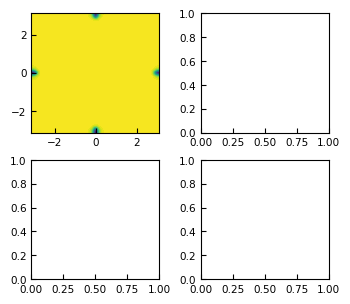

<Figure size 800x800 with 0 Axes>

In [2]:
# A' in equation (12)
fig, axs = plt.subplots(2, 2, figsize=(3.386, 2.093*1.4))
def spectrum_prime(kx, ky, omega, epsilon, epsilon_Q, mu, U, T):
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)
    spectrum_prime = (1 - n_k)*n_k*U/(2*epsilon-2*mu+U)*(lorentzian(omega - (band(kx, ky)+U - mu)) -lorentzian(omega - (band(kx, ky) - mu)))
    return spectrum_prime

Nk = 256
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

spectrum_prime_2d = np.full_like(KX, 0)
epsilon = band(KX, KY)
epsilon_Q = band_Q(KX, KY)
spectrum_prime_2d = spectrum_prime(KX, KY, 0, epsilon, epsilon_Q, mu, U, T)

fig = plt.figure(figsize=(8, 8))
N_levels = 40
# np.save(f'spectrum_K{Nk}_U={U}_mu={mu}', spectrum_2d)
axs[0, 0].contourf(KX, KY, spectrum_prime_2d, cmap="viridis", levels=N_levels)